# Fractional Brownian Motion

Ordinary Brownian motion has **no memory**. Where it goes next has nothing to do with where it has just been. **Fractional Brownian motion** gives it a memory, controlled by one number, `hurst`:

| `hurst` | What the path does | How it looks |
|---|---|---|
| below 0.5 | reverses itself -- up tends to be followed by down | jagged, spiky |
| exactly 0.5 | no memory at all | ordinary Brownian motion |
| above 0.5 | keeps going the same way | smooth, long trends |

The `hurst > 0.5` case is called *long-range dependence*, and it is why the process shows up in finance and in modeling network traffic. Like Brownian motion it starts at 0, and each draw is a sample path -- a function of continuous time.

In [1]:
from symbulate import *

## Create a process and draw a path

Each draw is a function of continuous time. Evaluate it at any time `t` to get the value at that moment. The value at time 0 is always exactly 0.

In [2]:
X = FractionalBrownianMotion(hurst=0.8)
path = X.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5, 10]]

[0.0, 1.41, 2.01, 2.91, 3.07]

## Simulate and plot sample paths

With `hurst = 0.8` the paths keep heading whichever way they were already going, so they look smooth and drift a long way from 0.

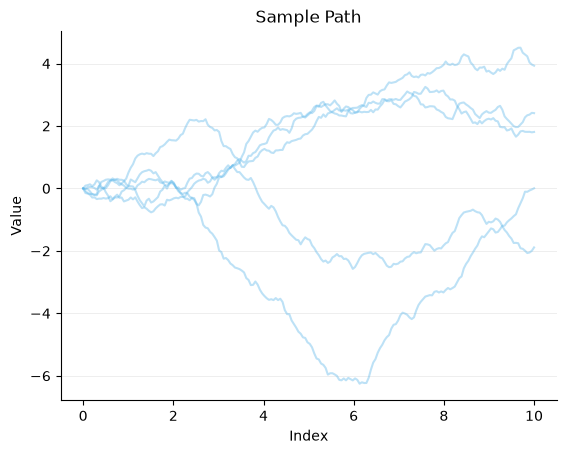

In [3]:
X.sim(5).plot(tmin=0, tmax=10)

## A small hurst gives a jagged path

With `hurst = 0.2` every step tends to be undone by the next one, so the path is spiky and stays much closer to 0. Compare the y-axis with the plot above.

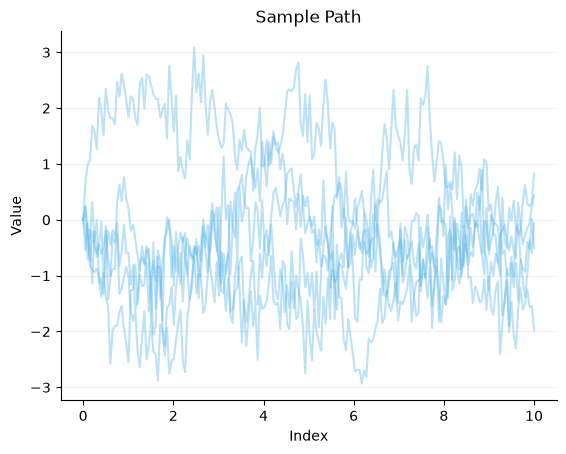

In [4]:
FractionalBrownianMotion(hurst=0.2).sim(5).plot(tmin=0, tmax=10)

## `hurst = 0.5` is ordinary Brownian motion

This is not an approximation -- at `hurst = 0.5` the covariance formula reduces exactly to Brownian motion's `min(s, t)`. So this plot and a `BrownianMotion` plot are pictures of the same process.

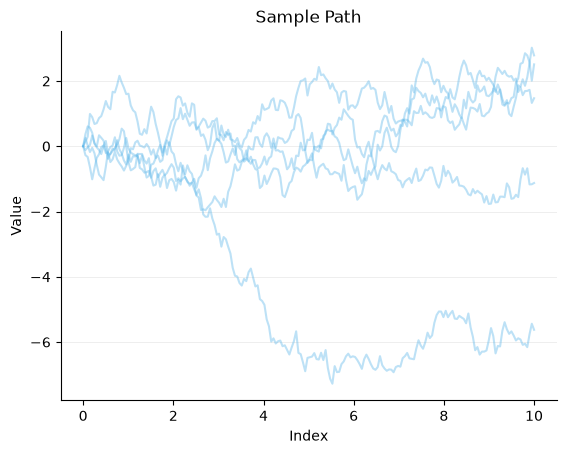

In [5]:
FractionalBrownianMotion(hurst=0.5).sim(5).plot(tmin=0, tmax=10)

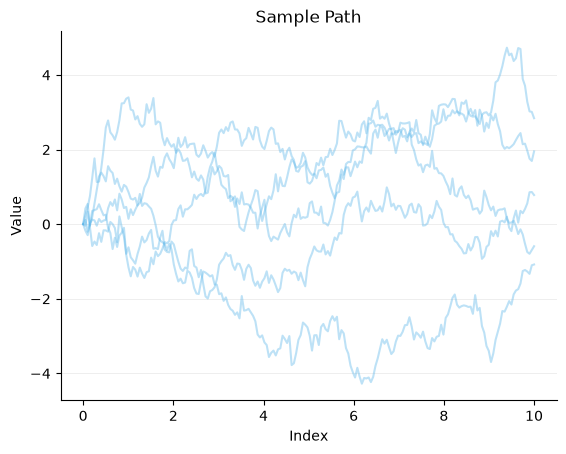

In [6]:
BrownianMotion().sim(5).plot(tmin=0, tmax=10)

## How much it wanders

`scale` sets the overall size of the wiggles, the same way it does for `BrownianMotion`.

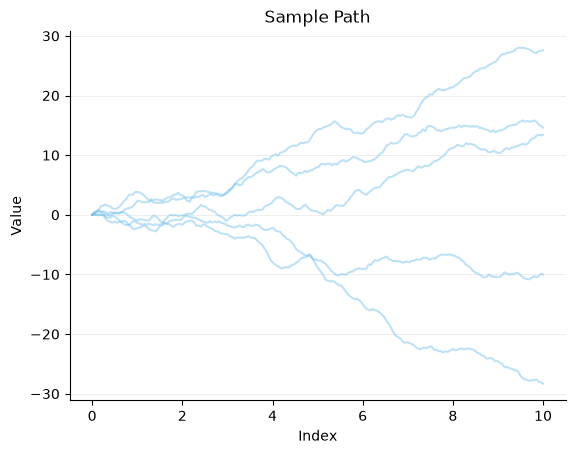

In [7]:
FractionalBrownianMotion(hurst=0.8, scale=3).sim(5).plot(tmin=0, tmax=10)

## The value at a fixed time

The value at a particular time is itself a random variable. Index the process at a time, `X[t]`, to get it. Its spread is `scale**2 * t**(2 * hurst)`, so at `t = 4` with `hurst = 0.8` that is `4**1.6` = about 9.2.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


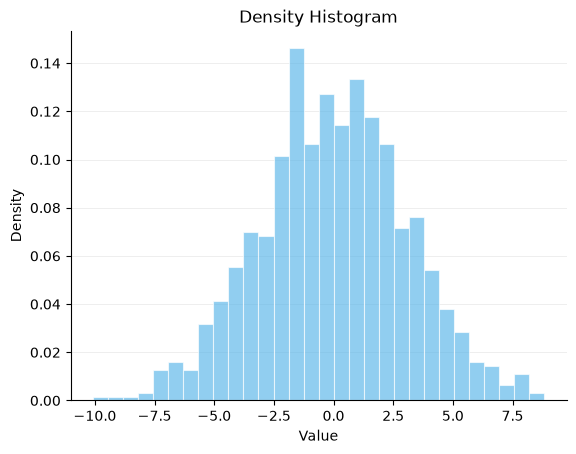

In [8]:
X[4.0].sim(1000).plot()

In [9]:
values = X[4.0].sim(1000)
values.mean(), values.var()

(-0.16381961052916158, 9.077122431774136)

A bigger `hurst` spreads out faster. At the same time `t = 4`, `hurst = 0.2` gives a spread of only `4**0.4` = about 1.7.

In [10]:
FractionalBrownianMotion(hurst=0.2)[4.0].sim(1000).var()

1.8459052936991382

## The memory, measured

Here is the memory as a number. Take the value at time 1, and the *change* from time 1 to time 2, and see whether they move together:

- above 0.5 -- **positive**: having gone up, it keeps going up
- exactly 0.5 -- **zero**: the change is unrelated to the past
- below 0.5 -- **negative**: having gone up, it tends to come back down

In [11]:
for hurst in [0.2, 0.5, 0.8]:
    Y = FractionalBrownianMotion(hurst=hurst)
    together = (Y[1.0] & (Y[2.0] - Y[1.0])).sim(2000).cov()
    print(f"hurst = {hurst}:  {together: .3f}")

hurst = 0.2:  -0.311


hurst = 0.5:  -0.010
hurst = 0.8:   0.484


## A note on speed

Every new time you ask a path about is drawn conditional on every time already drawn, which keeps the whole path consistent. The cost of that grows with each point added, so evaluating a single path at many hundreds of times gets slow. This is true of every Gaussian process in Symbulate, but it matters most here: with a large `hurst` the long memory is the whole point, so far-apart points genuinely cannot be ignored.

In practice, plotting a handful of paths or simulating `X[t]` at a few times is quick. Asking one path for thousands of time points is what to avoid.